Inspired from the research papers -

* **You are in a drawdown. When should you start worrying?**
Adam Rej, Philip Seager & Jean-Philippe Bouchaud
Capital Fund Management, 23 rue de l’Université, 75007 Paris

* **Drawdown Risk Beyond Brownian Motion**
A Monte-Carlo Framework, Non-Gaussian Extensions, and Long Memory
Francesco Landolfi
Epiphany, Imperia, Italy


## What is the RSB Model?

The **RSB (Rej–Seager–Bouchaud) Model** is a quantitative framework used to determine whether a trading strategy's **drawdown is statistically normal or unusually severe** given its assumed **Sharpe ratio**. :contentReference[oaicite:0]{index=0}

It models strategy P&L as a **drifted Brownian motion**:

$$
dPnL = \mu\,dt + \sigma\,dW
$$

where the drift $\mu$ represents the strategy's Sharpe ratio after normalizing volatility. :contentReference[oaicite:1]{index=1}

The model mainly evaluates:

- **Drawdown depth** — how much the strategy falls from its peak.
- **Drawdown length** — how long the strategy remains in drawdown.

RSB provides probability distributions and **5% extreme thresholds** for these measures. If the actual drawdown exceeds these thresholds, it becomes a warning that the assumed Sharpe ratio or model may need to be reconsidered. :contentReference[oaicite:2]{index=2}

### In Simple Terms

> **RSB tells us how much and how long a strategy can normally suffer for a given Sharpe ratio, and helps identify unusually bad drawdowns.**

# **Risk Measurement Functions**

These five functions each take a list of price paths (real or simulated) and
extract one specific risk statistic per path. All five share the same core
idea: track the running maximum price reached so far, and measure something
about how the price behaves relative to that peak.

### 1. `drawdown()` — Maximum Drawdown
For each path, tracks the running peak price at every point in time, then
measures the gap between that peak and the current price (peak − current).
The function returns the single largest gap observed across the whole path —
the worst peak-to-trough decline. This is the headline number: "how deep did
the worst losing streak get."

### 2. `max_loss()` — Maximum Loss
Measures the total swing in the path — the difference between the highest
and lowest values it ever reached. Unlike drawdown, this doesn't require the
low point to come *after* the high point in time; it's a simpler, broader
measure of how much the price moved from its best to its worst level overall.

### 3. `days_of_lower()` — Final Negative Time
Counts how many days, out of the whole path, the price spent *below* its
running peak (i.e., "underwater," not at a new high). A high value means the
strategy spent most of its life recovering or losing ground rather than
sitting at new highs.

### 4. `recovery_days()` — Longest Recovery Time
Finds the longest unbroken stretch of consecutive days spent underwater.
This captures duration specifically — not how deep the loss was, but how
long the strategy was stuck below its peak before it either recovered or the
path ended.

### 5. `last_neg()` — Last Negative Streak
Tracks a running cumulative sum of daily returns and records the last point
in the path where that running sum was negative. This captures how recently
(and for how long, near the end) the strategy was in a losing streak —
useful for understanding whether the pain is old news or still ongoing as of
the most recent data.

---

### Why Five Separate Measures Instead of One
A strategy can look fine on one measure and concerning on another — e.g., a
shallow but very long-lasting drawdown, or a deep but quickly-recovered one.
Using all five together (rather than relying on drawdown alone) gives a
fuller picture of *how* a strategy is behaving abnormally, not just *whether*
it is.

## Strategy Validation Rules

| Percentile Range | Health Status | Interpretation |
|---|---|---|
| **< 50th percentile** | 🟢 **Healthy** | Strategy is performing better than most Monte Carlo outcomes |
| **50th–90th percentile** | 🟡 **Normal** | Strategy is within the expected range |
| **90th–95th percentile** | 🟠 **Borderline** | Strategy is deteriorating and showing elevated risk |
| **> 95th percentile** | 🔴 **Breaking** | Strategy is performing significantly worse than expected and may be unstable |

### Overall Classification Rule

- **< 50th percentile** → 🟢 **Healthy**
- **50th–90th percentile** → 🟡 **Normal**
- **90th–95th percentile** → 🟠 **Borderline**
- **> 95th percentile** → 🔴 **Breaking**

> **If any critical risk metric exceeds the 95th percentile, the overall strategy is classified as 🔴 Breaking.**

### Interpretation

The percentile represents how extreme the strategy's observed outcome is compared with the outcomes generated by the Monte Carlo simulations.

- **30th percentile** → 🟢 Healthy
- **70th percentile** → 🟡 Normal
- **93rd percentile** → 🟠 Borderline
- **99th percentile** → 🔴 Breaking

# **Necessary Libraries and Data Import**

In [1]:
!pip install ta mplfinance

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 2.1 MB/s eta 0:00:00
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=b42f74a758e52b437ccefa75d71e7d92c81c1244e3ab75f4a41f6176a880fe8a
  Stored in directory: /root/.cache/pip/wheels/e3/3a/ee/4955a26c90a4b7deb6d725dc8ec7b8604a7aef44e43a2e8af7
Successfully built ta


In [2]:
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import time
import ta
import mplfinance as mpl

In [3]:
def Data():
  print('you can either give ur data or enter ticker of the asset')
  time.sleep(2)

  data=input()

  if data.endswith('.csv'):
    Data=pd.read_csv(data)
  else:
    ticker=yf.Ticker(data)
    df=ticker.history(period='1y')
    df['returns']=df['Close'].shift(-1)-df['Close']
    Data=(df[['Close','returns']])



  print(Data.head())
  return Data

# **FUNCTIONS**

creates a plot of data's returns

In [4]:
def returns_plot(data):
  plt.plot(data['returns'])

creates a grid of plot of returns features

In [5]:
def plot_analyser(data,broken,healthy):

  fig, ax = plt.subplots(2, 2, figsize=(12, 8))

  # 1. Closing Price
  ax[0, 0].plot(data['Close'])
  ax[0, 0].set_title('Closing Price of the Asset')


  # 2. Returns
  ax[0, 1].plot(data['returns'])
  ax[0, 1].set_title('Returns Plot')


  # 3. Healthy vs Broken
  ax[1, 0].plot(healthy, label="healthy")
  ax[1, 0].plot(broken, label="broken")
  ax[1, 0].set_title('BROKEN vs HEALTHY')
  ax[1, 0].legend()


  # 4. Continuous Time Frame
  ax[1, 1].plot(range(len(healthy)), healthy, label="healthy")

  ax[1, 1].plot(
      range(len(healthy), len(healthy) + len(broken)),
      broken,
      label="broken"
  )

  ax[1, 1].set_title('BROKEN and HEALTHY in a Continuous Time Frame')
  ax[1, 1].legend()


  plt.tight_layout()
  plt.show()


DRAWDOWN CALCULATOR


In [6]:
def drawdown(l):
  s=[]
  subs=[]

  for i in l:
    f=[]
    diff=[]
    maxi=0
    for j in range(len(i)):
      if j==0:
        maxi=i[j]
        dd=maxi-(i[j])
        f.append(dd)
      elif i[j]>=maxi:
        maxi=i[j]
        dd=maxi-(i[j])
        f.append(dd)
      elif i[j]<maxi:
        dd=maxi-(i[j])

        f.append(dd)
    s.append(max(f))
  return s

MAX LOSS AFTER PEAK

In [7]:
def max_loss(gauss):
  maxi=[]

  for i in gauss:
    series=pd.Series(i)
    returns=series.shift(-1)-(series)
    returns = returns.dropna()

    sums=[]
    sum=0
    for i in returns:
      sum+=i
      sums.append(sum)
    maxi.append(max(0, -min(sums)))

  return maxi

DAYS AFTER PEAK

In [8]:
def days_of_lower(l):

  count=[]
  for i in l:
    maxi=0
    c=0
    for j in range(len(i)):

      if i[j]>=maxi:
        maxi=i[j]

      elif i[j]<maxi:
        c+=1


    count.append(c)

  return count

RECOVERY

In [9]:
def recovery_days(l):
  count = []

  for i in l:
      maxi = 0
      c = 0
      f = []

      for j in range(len(i)):

          if i[j] >= maxi:
              maxi = i[j]
              f.append(c)
              c = 0

          elif i[j] < maxi:
              c += 1
      f.append(c)
      count.append(max(f))

  return count

LAST NEGATIVE

In [10]:
def last_neg(gauss):
    neg = []
    for i in gauss:
        series = pd.Series(i)
        returns = series.diff().dropna()  # day-to-day changes, simpler than shift(-1) - series

        streak = 0
        last_streak_end = 0
        for j in range(len(returns)):
            if returns.iloc[j] < 0:
                streak += 1
                last_streak_end = j
            else:
                streak = 0   # reset when a positive day breaks the streak

        neg.append(last_streak_end if streak > 0 or last_streak_end > 0 else 0)
    return neg

gauss simulation for 1 year time frame

In [11]:
def gauss_1yr(total_simulations,days,avg_returns,volatility,last_price):
  l=[]
  for i in range(total_simulations):
    current_simulated_price = last_price
    f=[]
    for j in range(days):
      daily_random_return = np.random.normal(loc=avg_returns, scale=volatility)
      current_simulated_price = current_simulated_price * (1 + daily_random_return)
      f.append(current_simulated_price)
    l.append(f)

  return l

emperical simulation for 1 year time frame

In [12]:
def emperical_1yr(total_simulations,days,data,avg_returns,volatility,last_price):
  c=[]
  returns=data['returns']
  for i in range(total_simulations):
    current_simulated_price = last_price
    f=[]
    for j in range(days):
      daily_random_return = float(np.random.choice(returns))
      current_simulated_price = current_simulated_price * (1 + daily_random_return)
      f.append(current_simulated_price)
    c.append(f)
  return c

Monte Carlo Graph of Gauss Simulation

In [13]:
def gauss_graph(l):

    for i in l:
        plt.plot(i)

    plt.title('MONTE CARLO - GAUSSIAN')
    plt.show()

Monte Carlo Graph of Emperical Simulation

In [14]:
def emperical_graph(c):

    for i in c:
        plt.plot(i)

    plt.title('MONTE CARLO - EMPERICAL')
    plt.show()

Monte Carlo Graph of RSB Simulation

In [15]:
def rsb_graph(c):

    for i in c:
        plt.plot(i)

    plt.title('MONTE CARLO - RSB')
    plt.show()

Gauss Distribution Graph

In [16]:
def gauss_distribution(l):
  final_prices = []

  for simulation in l:
      final_prices.append(simulation[-1])

  plt.hist(final_prices,bins=80)
  plt.xlabel("Final Price")
  plt.ylabel("Number of Simulations")
  plt.title("Monte Carlo Distribution")
  plt.show()

Emperical Distribution Graph

In [17]:
def emperical_distribution(c):
  final_prices = []

  for simulation in c:
      final_prices.append(simulation[-1])

  plt.hist(final_prices,bins=80)
  plt.xlabel("Final Price")
  plt.ylabel("Number of Simulations")
  plt.title("Monte Carlo Distribution")
  plt.show()

RSB Distribution Graph

In [18]:
def rsb_distribution(c):
  final_prices = []

  for simulation in c:
      final_prices.append(simulation[-1])

  plt.hist(final_prices,bins=80)
  plt.xlabel("Final Price")
  plt.ylabel("Number of Simulations")
  plt.title("Monte Carlo Distribution")
  plt.show()

 **RSB MC**

In [19]:
def rsb_mc(annual_sharpe, days,total_simulations):  # RSB Monte Carlo

    rsb_daily_drift = annual_sharpe / 252
    rsb_daily_volatility = 1 / np.sqrt(252)

    daily_returns = np.random.normal(
        loc=rsb_daily_drift,
        scale=rsb_daily_volatility,
        size=(total_simulations, days)
    )

    pnl_paths = np.cumsum(daily_returns, axis=1)

    rsb = pnl_paths.tolist()

    return rsb

**NORMALISED GAUSSIAN MC**

In [20]:
# ============================================================
# NORMALISED GAUSSIAN MC
# ============================================================

def norm_gauss_mc(avg_returns, volatility, days,total_simulations):

    daily_returns = np.random.normal(
        loc=avg_returns,
        scale=volatility,
        size=(total_simulations, days)
    )

    normalized_returns = daily_returns / (volatility * np.sqrt(252))

    pnl_paths = np.cumsum(normalized_returns, axis=1)

    gauss_norm = pnl_paths.tolist()

    return gauss_norm

**NORMALISED REALISTIC MC**

In [21]:
# ============================================================
# NORMALISED REALISTIC MC (vectorized)
# ============================================================
def emperical_norm_mc(volatility, data, days,total_simulations):

    returns = data['returns'].values

    # Draw all random returns at once: shape (total_simulations, days)
    sampled_returns = np.random.choice(returns, size=(total_simulations, days), replace=True)

    # Convert to RSB units
    normalized_returns = sampled_returns / (volatility * np.sqrt(252))

    # Cumulative sum along each simulation's path (equivalent to the running pnl loop)
    pnl_paths = np.cumsum(normalized_returns, axis=1)

    real_norm = pnl_paths.tolist()

    return real_norm

PERCENTILE CALCULATION

In [22]:
import numpy as np
import pandas as pd

def get_percentile_table_1yr(l, c):
    gaussian_drawdown = drawdown(l)
    real_drawdown     = drawdown(c)

    gauss_days = days_of_lower(l)
    real_days  = days_of_lower(c)

    gauss_recovery = recovery_days(l)
    real_recovery  = recovery_days(c)

    gauss_loss = max_loss(l)
    real_loss  = max_loss(c)

    gauss_neg = last_neg(l)
    real_neg  = last_neg(c)

    labels = ['gaussian_drawdown', 'real_drawdown',
              'gauss_days', 'real_days',
              'gauss_recovery', 'real_recovery',
              'gauss_loss', 'real_loss',
              'gauss_neg', 'real_neg']

    features = [gaussian_drawdown, real_drawdown,
                gauss_days, real_days,
                gauss_recovery, real_recovery,
                gauss_loss, real_loss,
                gauss_neg, real_neg]

    percentiles = []
    for i in features:
        percentiles.append(np.percentile(i, [50, 90, 95]))

    df = pd.DataFrame(percentiles, columns=['50th', '90th', '95th'], index=labels)

    return df


In [23]:
def get_percentile_table_norm(rsb_sim, gauss_norm, real_norm):
    rsb_drawdown = drawdown(rsb_sim)
    gauss_drawdown = drawdown(gauss_norm)
    real_drawdown = drawdown(real_norm)

    rsb_days = days_of_lower(rsb_sim)
    gauss_days = days_of_lower(gauss_norm)
    real_days = days_of_lower(real_norm)

    rsb_recovery = recovery_days(rsb_sim)
    gauss_recovery = recovery_days(gauss_norm)
    real_recovery = recovery_days(real_norm)

    rsb_loss = max_loss(rsb_sim)
    gauss_loss = max_loss(gauss_norm)
    real_loss = max_loss(real_norm)

    rsb_neg = last_neg(rsb_sim)
    gauss_neg = last_neg(gauss_norm)
    real_neg = last_neg(real_norm)

    labels = ['rsb_drawdown', 'gauss_drawdown', 'real_drawdown',
              'rsb_days', 'gauss_days', 'real_days',
              'rsb_recovery', 'gauss_recovery', 'real_recovery',
              'rsb_loss', 'gauss_loss', 'real_loss',
              'rsb_neg', 'gauss_neg', 'real_neg']

    features = [rsb_drawdown, gauss_drawdown, real_drawdown,
                rsb_days, gauss_days, real_days,
                rsb_recovery, gauss_recovery, real_recovery,
                rsb_loss, gauss_loss, real_loss,
                rsb_neg, gauss_neg, real_neg]

    percentiles = []
    for i in features:
        percentiles.append(np.percentile(i, [50, 90, 95]))

    df = pd.DataFrame(percentiles, columns=['50th', '90th', '95th'], index=labels)
    return df

**BROKEN FRAME FUNCTIONS**

In [24]:
def returns_to_price_path(returns):
    price_path = [last_price]
    current_price = last_price
    for r in returns:
        current_price = current_price * (1 + r)
        price_path.append(current_price)
    return price_path[1:]


In [25]:
def broken_metrics(data):

  dd=drawdown(data)
  loss=max_loss(data)
  days=days_of_lower(data)
  recovery=recovery_days(data)
  neg=last_neg(data)

  df=pd.DataFrame()

  df['Broken_drawdown']=dd
  df['Max_Loss']=loss
  df['Days_Of_Recovery']=recovery
  df['Days_Of_Lower']=days
  df['Last_Negative']=neg


  return df

In [26]:
def normalized_broken_metrics(broken):
  broken_price_path = returns_to_price_path(broken)

  asset_dd=drawdown([broken_price_path])
  asset_loss=max_loss([broken_price_path])
  asset_recovery_days=recovery_days([broken_price_path])
  asset_days_of_lower=days_of_lower([broken_price_path])
  asset_last_neg=last_neg([broken_price_path])

  normalized_drawdown=asset_dd/(last_price * volatility * np.sqrt(252))
  normalized_loss=asset_loss/(last_price * volatility * np.sqrt(252))
  normalized_days=asset_days_of_lower
  normalized_recovery=asset_recovery_days
  normalized_neg=asset_last_neg

  df=pd.DataFrame()

  df['Broken_drawdown']=normalized_drawdown
  df['Max_Loss']=normalized_loss
  df['Days_Of_Recovery']=normalized_recovery
  df['Days_Of_Lower']=normalized_days
  df['Last_Negative']=normalized_neg

  return df



In [27]:
def broken_metrics_percentile_1yr(broken,l,c):
  broken_price_path = returns_to_price_path(broken)

  asset_dd=drawdown([broken_price_path])
  asset_loss=max_loss([broken_price_path])
  asset_recovery_days=recovery_days([broken_price_path])
  asset_days_of_lower=days_of_lower([broken_price_path])
  asset_last_neg=last_neg([broken_price_path])

  gaussian_drawdown = drawdown(l)
  real_drawdown     = drawdown(c)

  gauss_days = days_of_lower(l)
  real_days  = days_of_lower(c)

  gauss_recovery = recovery_days(l)
  real_recovery  = recovery_days(c)

  gauss_loss = max_loss(l)
  real_loss  = max_loss(c)

  gauss_neg = last_neg(l)
  real_neg  = last_neg(c)

  from scipy.stats import percentileofscore

  # Gaussian MC
  gauss_drawdown_percentile = percentileofscore(gaussian_drawdown, asset_dd)
  gauss_loss_percentile = percentileofscore(gauss_loss, asset_loss)
  gauss_days_percentile = percentileofscore(gauss_days, asset_days_of_lower)
  gauss_recovery_percentile = percentileofscore(gauss_recovery, asset_recovery_days)
  gauss_neg_percentile = percentileofscore(gauss_neg, asset_last_neg)

  # Realistic MC
  real_drawdown_percentile = percentileofscore(real_drawdown, asset_dd)
  real_loss_percentile = percentileofscore(real_loss, asset_loss)
  real_days_percentile = percentileofscore(real_days, asset_days_of_lower)
  real_recovery_percentile = percentileofscore(real_recovery, asset_recovery_days)
  real_neg_percentile = percentileofscore(real_neg, asset_last_neg)

  # Combined table
  final_1yr = pd.DataFrame({
      "Gaussian MC": [gauss_drawdown_percentile, gauss_loss_percentile, gauss_days_percentile, gauss_recovery_percentile, gauss_neg_percentile],
      "Realistic MC": [real_drawdown_percentile, real_loss_percentile, real_days_percentile, real_recovery_percentile, real_neg_percentile]
  }, index=["Drawdown", "Max Loss", "Days Lower", "Recovery", "Final Negative"])

  return final_1yr


In [28]:
def broken_metrics_percentile(broken,rsb,gauss_norm,real_norm):
  broken_price_path = returns_to_price_path(broken)

  asset_dd=drawdown([broken_price_path])
  asset_loss=max_loss([broken_price_path])
  asset_recovery_days=recovery_days([broken_price_path])
  asset_days_of_lower=days_of_lower([broken_price_path])
  asset_last_neg=last_neg([broken_price_path])

  normalized_drawdown=asset_dd/(last_price * volatility * np.sqrt(252))
  normalized_loss=asset_loss/(last_price * volatility * np.sqrt(252))
  normalized_days=asset_days_of_lower
  normalized_recovery=asset_recovery_days
  normalized_neg=asset_last_neg


  rsb_drawdown = drawdown(rsb)
  rsb_max_loss = max_loss(rsb)
  rsb_days = days_of_lower(rsb)
  rsb_recovery = recovery_days(rsb)
  rsb_neg = last_neg(rsb)

  gauss_norm_drawdown = drawdown(gauss_norm)
  gauss_norm_loss = max_loss(gauss_norm)
  gauss_norm_days = days_of_lower(gauss_norm)
  gauss_norm_recovery = recovery_days(gauss_norm)
  gauss_norm_neg = last_neg(gauss_norm)


  real_norm_drawdown = drawdown(real_norm)
  real_norm_loss = max_loss(real_norm)
  real_norm_days = days_of_lower(real_norm)
  real_norm_recovery = recovery_days(real_norm)
  real_norm_neg = last_neg(real_norm)

  from scipy.stats import percentileofscore

  # ---------- RSB MC ----------
  rsb_drawdown_percentile = percentileofscore(rsb_drawdown, normalized_drawdown)
  rsb_loss_percentile = percentileofscore(rsb_max_loss, normalized_loss)
  rsb_days_percentile = percentileofscore(rsb_days, normalized_days)
  rsb_recovery_percentile = percentileofscore(rsb_recovery, normalized_recovery)
  rsb_neg_percentile = percentileofscore(rsb_neg, normalized_neg)

  # ---------- Gaussian MC ----------
  gauss_drawdown_percentile = percentileofscore(gauss_norm_drawdown, normalized_drawdown)
  gauss_loss_percentile = percentileofscore(gauss_norm_loss, normalized_loss)
  gauss_days_percentile = percentileofscore(gauss_norm_days, normalized_days)
  gauss_recovery_percentile = percentileofscore(gauss_norm_recovery, normalized_recovery)
  gauss_neg_percentile = percentileofscore(gauss_norm_neg, normalized_neg)

  # ---------- Realistic MC ----------
  real_drawdown_percentile = percentileofscore(real_norm_drawdown, normalized_drawdown)
  real_loss_percentile = percentileofscore(real_norm_loss, normalized_loss)
  real_days_percentile = percentileofscore(real_norm_days, normalized_days)
  real_recovery_percentile = percentileofscore(real_norm_recovery, normalized_recovery)
  real_neg_percentile = percentileofscore(real_norm_neg, normalized_neg)

  # ---------- Combined table ----------
  final_10yr = pd.DataFrame({
      "RSB MC": [rsb_drawdown_percentile, rsb_loss_percentile, rsb_days_percentile, rsb_recovery_percentile, rsb_neg_percentile],
      "Gaussian MC": [gauss_drawdown_percentile, gauss_loss_percentile, gauss_days_percentile, gauss_recovery_percentile, gauss_neg_percentile],
      "Realistic MC": [real_drawdown_percentile, real_loss_percentile, real_days_percentile, real_recovery_percentile, real_neg_percentile]
  }, index=["Drawdown", "Max Loss", "Days Lower", "Recovery", "Final Negative"])

  return final_10yr

# **1YR DATA**

DATA ENGINNERING - this is a manual task to divide and seprate the broken part and the healthy part (automating this is a future work)

In [29]:
data=Data()

you can either give ur data or enter ticker of the asset
/content/bad_strategy_returns.csv
         date       Close   returns
0  2024-08-12  102.088631  0.020886
1  2024-08-13  101.579081 -0.004991
2  2024-08-14  101.680035  0.000994
3  2024-08-15  102.238278  0.005490
4  2024-08-16  101.331723 -0.008867


In [ ]:
data.rename(columns={'synthetic_close': 'Close'}, inplace=True)

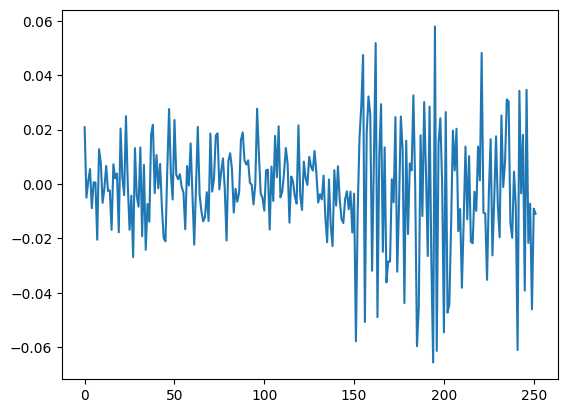

In [30]:
returns_plot(data)

In [33]:
import pandas as pd

# Load the 1-year synthetic strategy data
returns = data['returns'].values
close=data['Close'].values

# Known breakdown point (engineered at day 150 for the 1yr dataset)
breakdown_point = int(input('enter the breaking point : '))
time.sleep(2)

# Split into healthy and broken segments
healthy = returns[:breakdown_point]
healthy_close=close[:breakdown_point]
broken  = returns[breakdown_point:]
broken_close=close[breakdown_point:]

print("Healthy days:", len(healthy))
print("Broken days:", len(broken))




enter the breaking point : 150
Healthy days: 150
Broken days: 102


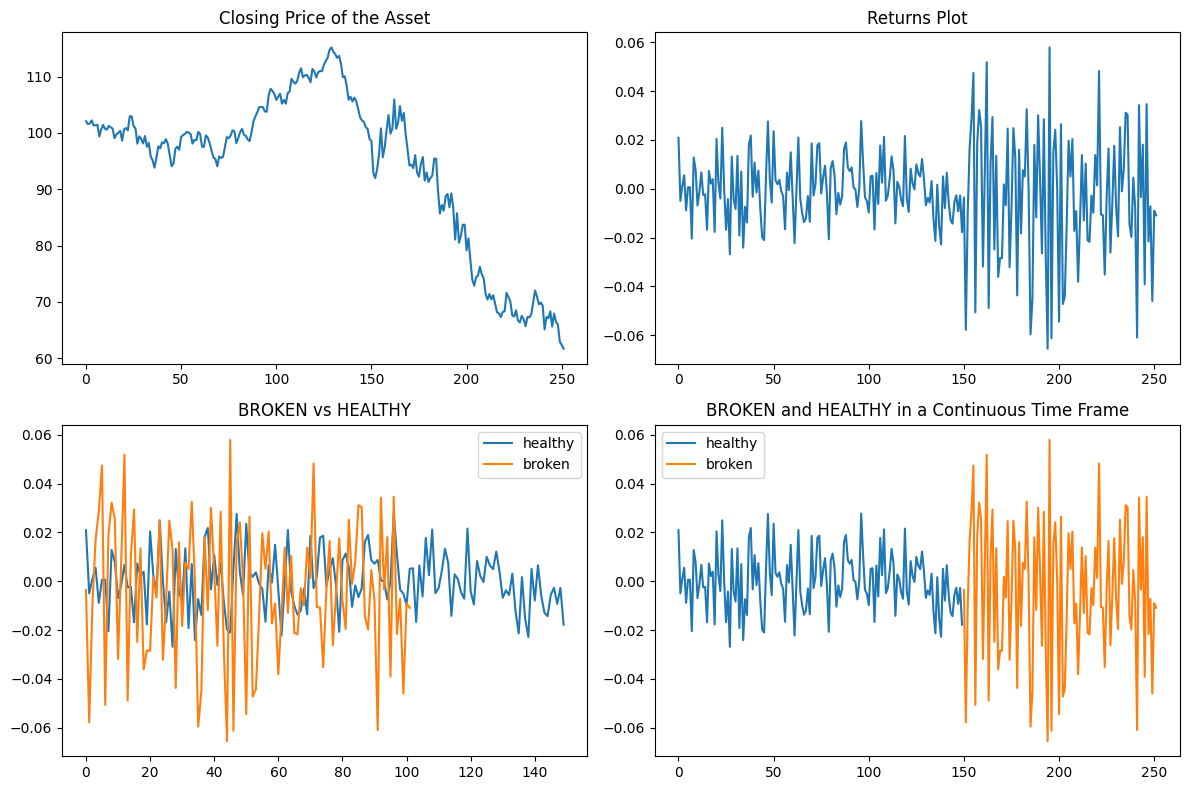

In [34]:
plot_analyser(data,broken,healthy)

In [35]:
def dataframe(l):

  cols=['returns']

  data=pd.DataFrame(l,columns=cols)
  return data

CALCULATION TERMS

In [36]:
days = 252
total_simulations = 10000

simulations = [[0] * days for _ in range(total_simulations)]


last_price = data['Close'].iloc[breakdown_point - 1]

avg_returns = healthy.mean()
volatility   = healthy.std()

mu = avg_returns * days
standard_volatility = volatility * np.sqrt(days)

sharpe = avg_returns / volatility
annual_sharpe = sharpe * np.sqrt(252)

sharpe, avg_returns, volatility, annual_sharpe

(np.float64(-0.0002201416349536889),
 np.float64(-2.559580177494275e-06),
 np.float64(0.0116269699642811),
 np.float64(-0.0034946401157917493))

In [37]:
healthy=dataframe(healthy)

# **1 YEAR MODEL**

**MONTE CARLO - GAUSSIAN**

In [38]:
l=gauss_1yr(total_simulations,len(broken),avg_returns,volatility,last_price)

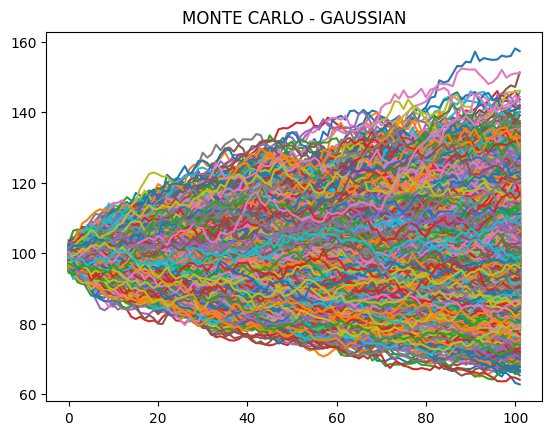

In [39]:
gauss_graph(l)

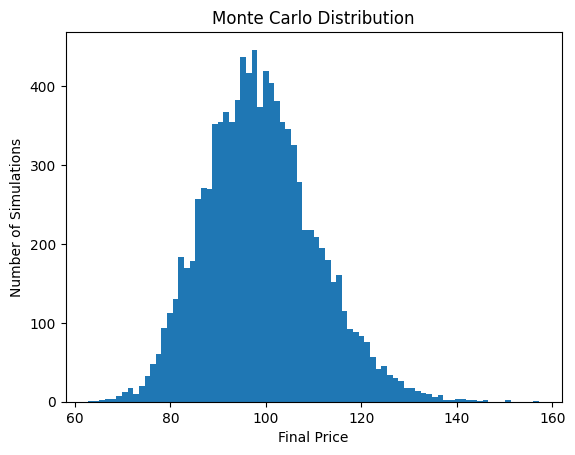

In [40]:
gauss_distribution(l)

**MONTE CARLO - EMPERICAL**


In [41]:
c=emperical_1yr(total_simulations,len(broken),healthy,avg_returns,volatility,last_price)

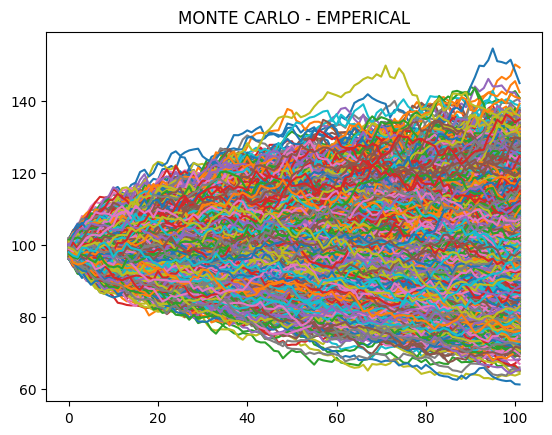

In [42]:
emperical_graph(c)

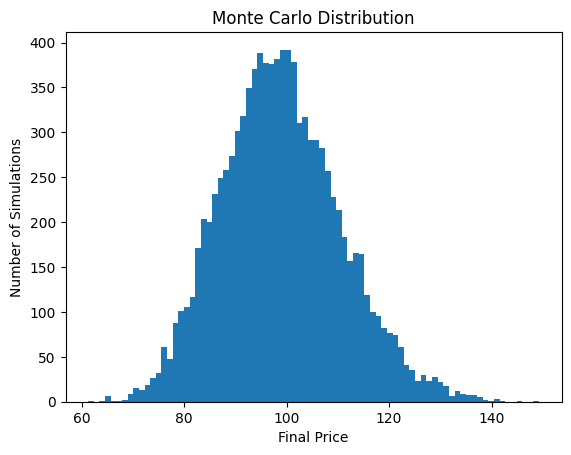

In [43]:
emperical_distribution(c)

**CALCULATING FEATURES OF HEALTHY DATA**

In [44]:
result_1yr=get_percentile_table_1yr(l, c)
result_1yr

,50th,90th,95th
gaussian_drawdown,12.371242,20.613635,23.121217
real_drawdown,12.217792,20.529198,23.177751
gauss_days,93.000000,100.000000,101.000000
real_days,93.000000,100.000000,101.000000
gauss_recovery,64.000000,99.000000,101.000000
real_recovery,64.000000,99.000000,101.000000
gauss_loss,7.274545,17.276749,20.108336
real_loss,7.104448,17.360159,20.225038
gauss_neg,100.000000,100.000000,100.000000
real_neg,100.000000,100.000000,100.000000


**CALCULATING BROKEN FRAME**

In [45]:
broken_price_path = returns_to_price_path(broken)
broken_metrics([broken_price_path])

,Broken_drawdown,Max_Loss,Days_Of_Recovery,Days_Of_Lower,Last_Negative
0,44.271165,36.927729,89,98,100


In [46]:
broken_metrics_percentile_1yr(broken,l,c)

,Gaussian MC,Realistic MC
Drawdown,[100.0],[100.0]
Max Loss,[100.0],[99.99000000000001]
Days Lower,[79.635],[78.895]
Recovery,[75.575],[74.95]
Final Negative,[74.935],[74.175]


# **10 YEAR MODEL**
RSB APPROACH

# **DATA CREATION**



---



TESTING STRATEGY

In [52]:
import yfinance as yf
import pandas as pd
import numpy as np

def generate_vol_targeted_momentum_10yr(ticker="RELIANCE.NS", start="2014-01-01", end="2024-01-01",
                                          lookback=126, vol_window=20, target_vol=0.15,
                                          max_leverage=2.0, txn_cost_bps=5):
    data = yf.download(ticker, start=start, end=end)
    close = data['Close'].squeeze()
    daily_returns = close.pct_change()

    # Trend signal: 6-month (126 trading day) momentum
    momentum = close.pct_change(lookback)
    raw_signal = np.sign(momentum)  # +1 long, -1 short, 0 flat

    # Realized volatility (annualized), used to size position
    realized_vol = daily_returns.rolling(vol_window).std() * np.sqrt(252)

    # Position size: scale exposure inversely to volatility, targeting a constant risk level
    position_size = (target_vol / realized_vol).clip(upper=max_leverage)
    position = (raw_signal * position_size).shift(1).fillna(0)

    # Transaction costs: charged whenever position changes
    position_change = position.diff().abs().fillna(0)
    txn_costs = position_change * (txn_cost_bps / 10000)

    strategy_returns = (position * daily_returns) - txn_costs
    strategy_returns = strategy_returns.fillna(0)

    df = pd.DataFrame({
        'close': close,
        'returns': strategy_returns
    }).dropna()

    return df

df_momentum_10yr = generate_vol_targeted_momentum_10yr()
df_momentum_10yr.to_csv('vol_targeted_momentum_10yr.csv')
df_momentum_10yr

/tmp/ipykernel_1208/1878461746.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start=start, end=end)
[*********************100%***********************]  1 of 1 completed


,close,returns
Date,,
2014-01-01,187.467300,0.000000
2014-01-02,184.556580,-0.000000
2014-01-03,182.289185,-0.000000
2014-01-06,180.327621,-0.000000
2014-01-07,177.617264,-0.000000
...,...,...
2023-12-22,1267.243042,0.001059
2023-12-26,1273.665527,0.005614
2023-12-27,1278.013184,0.003801


In [55]:
data=Data()

you can either give ur data or enter ticker of the asset
/content/vol_targeted_momentum_10yr.csv
         Date       close  returns
0  2014-01-01  187.467300      0.0
1  2014-01-02  184.556580     -0.0
2  2014-01-03  182.289185     -0.0
3  2014-01-06  180.327621     -0.0
4  2014-01-07  177.617264     -0.0


In [57]:
data.rename(columns={'close':'Close'},inplace=True)

In [81]:
import pandas as pd

# Load the 1-year synthetic strategy data
returns = data['returns'].values
close=data['Close'].values

# Known breakdown point (engineered at day 150 for the 1yr dataset)
breakdown_point = int(input('enter the breaking point : '))
time.sleep(2)


# Split into healthy and broken segments
healthy = returns[:breakdown_point]
healthy_close=close[:breakdown_point]
broken  = returns[breakdown_point:]
broken_close=close[breakdown_point:]

print("Healthy days:", len(healthy))
print("Broken days:", len(broken))



enter the breaking point : 765
Healthy days: 765
Broken days: 1700


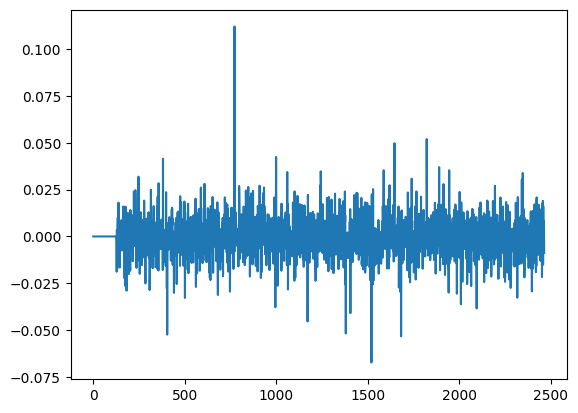

In [77]:
returns_plot(data)

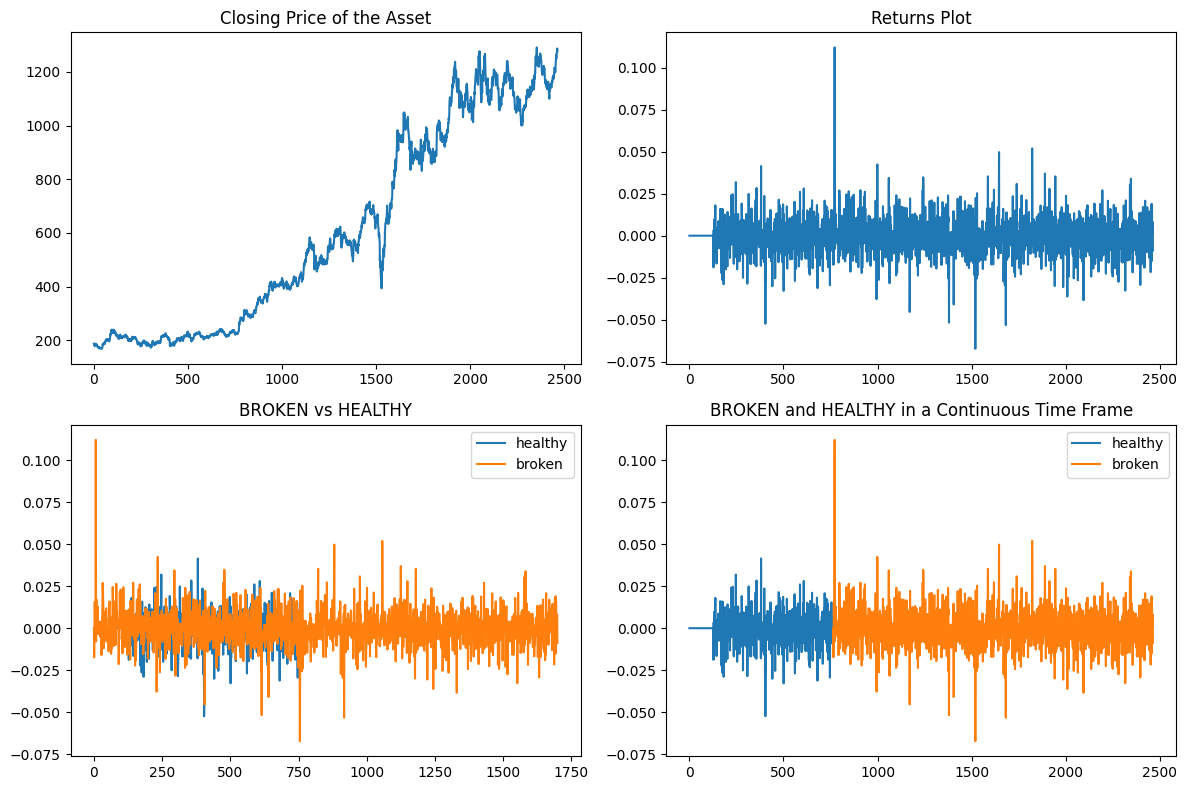

In [82]:
plot_analyser(data,broken,healthy)

In [83]:
days = 2520
total_simulations = 10000

simulations = [[0] * days for _ in range(total_simulations)]


last_price = data['Close'].iloc[breakdown_point - 1]

avg_returns = healthy.mean()
volatility   = healthy.std()

mu = avg_returns * days
standard_volatility = volatility * np.sqrt(days)

sharpe = avg_returns / volatility
annual_sharpe = sharpe * np.sqrt(252)

sharpe, avg_returns, volatility, annual_sharpe

(np.float64(-0.04841874081127571),
 np.float64(-0.0004448424655741147),
 np.float64(0.009187402607349926),
 np.float64(-0.7686236818891758))

In [84]:
healthy=dataframe(healthy)

# **MODEL**

RSB METRICS

In [85]:
rsb_depth=1.50/annual_sharpe
rsb_length=2.14 / (annual_sharpe ** 2)

rsb_depth,rsb_length

(np.float64(-1.9515401819433893), np.float64(3.622315304410144))

MONTE CARLO SIMULATIONS

In [86]:
gauss_norm = norm_gauss_mc(avg_returns, volatility, len(broken),10000)

In [87]:
real_norm  = emperical_norm_mc(volatility, healthy, len(broken),10000)

In [88]:
rsb_sim = rsb_mc(annual_sharpe, len(broken),10000)

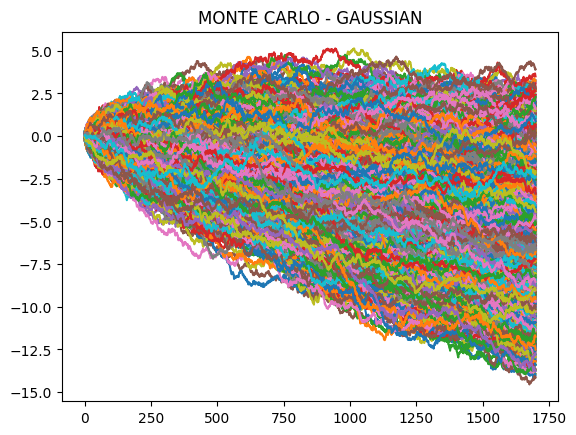

In [89]:
gauss_graph(gauss_norm)

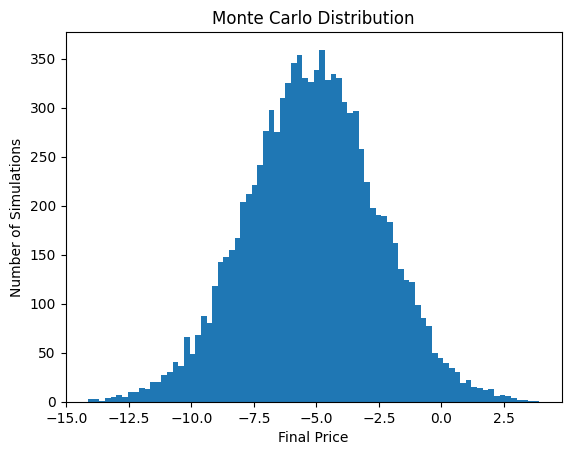

In [90]:
gauss_distribution(gauss_norm)

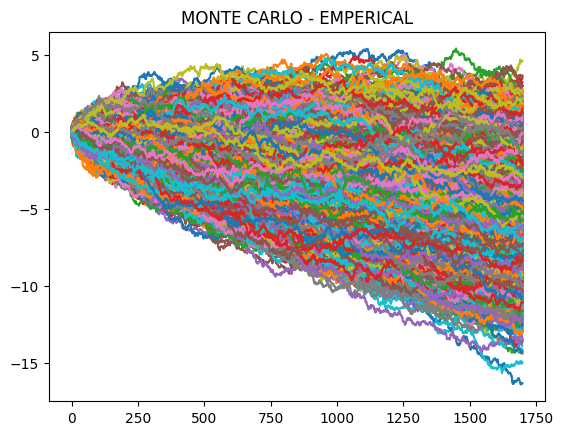

In [91]:
emperical_graph(real_norm)

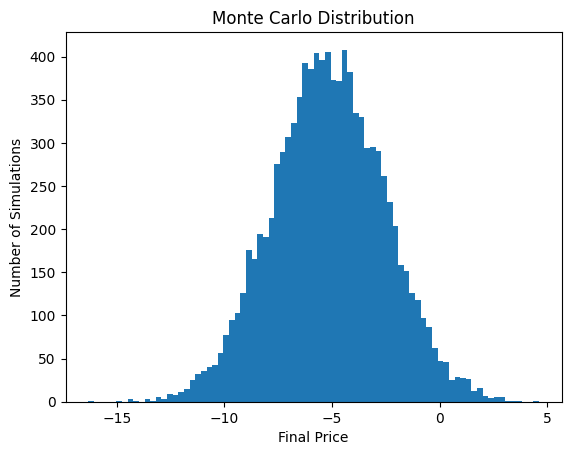

In [92]:
emperical_distribution(real_norm)

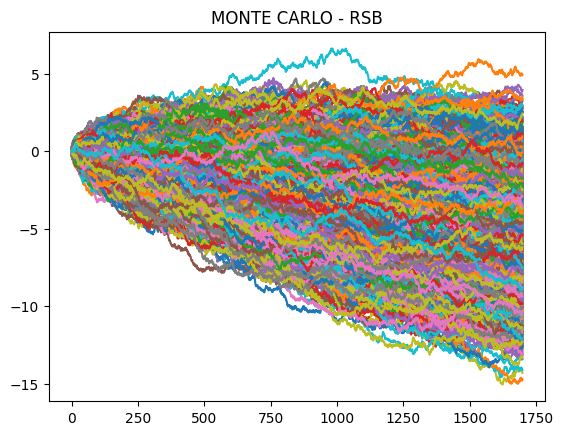

In [93]:
rsb_graph(rsb_sim)

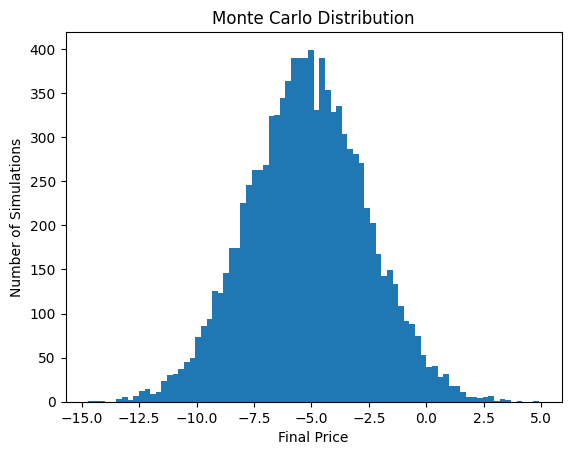

In [94]:
rsb_distribution(rsb_sim)

BROKEN 5

In [95]:
get_percentile_table_norm(rsb_sim, gauss_norm, real_norm)

,50th,90th,95th
rsb_drawdown,6.222280,9.243926,10.077206
gauss_drawdown,6.219201,9.257557,10.115120
real_drawdown,6.219458,9.242620,10.130953
rsb_days,1690.000000,1699.000000,1700.000000
gauss_days,1690.000000,1699.000000,1700.000000
real_days,1689.000000,1699.000000,1700.000000
rsb_recovery,1633.500000,1699.000000,1700.000000
gauss_recovery,1631.000000,1699.000000,1700.000000
real_recovery,1629.000000,1698.000000,1700.000000
rsb_loss,5.726303,8.865870,9.755105


In [96]:
broken_price_path = returns_to_price_path(broken)
broken_5=broken_metrics([broken_price_path])
broken_5

,Broken_drawdown,Max_Loss,Days_Of_Recovery,Days_Of_Lower,Last_Negative
0,213.767905,27.885558,1154,1626,1698


In [97]:
normalized_broken_metrics(broken)

,Broken_drawdown,Max_Loss,Days_Of_Recovery,Days_Of_Lower,Last_Negative
0,6.523238,0.850942,1154,1626,1698


In [98]:
broken_metrics_percentile(broken,rsb_sim,gauss_norm,real_norm)

,RSB MC,Gaussian MC,Realistic MC
Drawdown,[55.15],[55.33],[55.27]
Max Loss,[1.06],[1.18],[1.16]
Days Lower,[0.605],[0.465],[0.92]
Recovery,[9.76],[10.425],[10.38]
Final Negative,[73.87],[74.265],[78.61]
